In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv("data/chemist_store.csv")

In [6]:
df.head()

,Invoice_ID,Date,Customer_ID,Gender,Age,Medicine_Name,Category,Brand,Quantity,Unit_Price,Discount,Total_Price,Payment_Method,Supplier,Stock,Expiry_Date,City
0,INV0001,2025-01-20,CUST033,Male,57,ORS,Hydration,Mankind,3,250,0,750.00,Card,CareDist,143,2026-06-23,Siliguri
1,INV0002,2025-02-24,CUST067,Male,27,Omeprazole,Gastric,Dr. Reddy's,4,120,10,432.00,Card,HealthPlus,80,2026-06-17,Kolkata
2,INV0003,2025-03-19,CUST105,Female,74,Vitamin C,Vitamin,Cipla,3,35,15,89.25,Card,PharmaLink,123,2026-10-08,Durgapur
3,INV0004,2025-01-07,CUST032,Female,22,Pantoprazole,Gastric,Abbott,4,50,10,180.00,Card,CareDist,94,2026-01-16,Siliguri
4,INV0005,2025-04-08,CUST080,Female,61,Paracetamol,Pain Relief,Dr. Reddy's,1,50,10,45.00,Cash,PharmaLink,175,2026-12-05,Kolkata


In [7]:
df.shape

(300, 17)

In [8]:
df.columns

Index(['Invoice_ID', 'Date', 'Customer_ID', 'Gender', 'Age', 'Medicine_Name',
       'Category', 'Brand', 'Quantity', 'Unit_Price', 'Discount',
       'Total_Price', 'Payment_Method', 'Supplier', 'Stock', 'Expiry_Date',
       'City'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Invoice_ID      300 non-null    object 
 1   Date            300 non-null    object 
 2   Customer_ID     300 non-null    object 
 3   Gender          300 non-null    object 
 4   Age             300 non-null    int64  
 5   Medicine_Name   300 non-null    object 
 6   Category        300 non-null    object 
 7   Brand           300 non-null    object 
 8   Quantity        300 non-null    int64  
 9   Unit_Price      300 non-null    int64  
 10  Discount        300 non-null    int64  
 11  Total_Price     300 non-null    float64
 12  Payment_Method  300 non-null    object 
 13  Supplier        300 non-null    object 
 14  Stock           300 non-null    int64  
 15  Expiry_Date     300 non-null    object 
 16  City            300 non-null    object 
dtypes: float64(1), int64(5), object(11)

In [10]:
df.isnull().sum()

Invoice_ID        0
Date              0
Customer_ID       0
Gender            0
Age               0
Medicine_Name     0
Category          0
Brand             0
Quantity          0
Unit_Price        0
Discount          0
Total_Price       0
Payment_Method    0
Supplier          0
Stock             0
Expiry_Date       0
City              0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,Age,Quantity,Unit_Price,Discount,Total_Price,Stock
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,47.353333,3.073333,105.250000,7.166667,295.564167,100.813333
std,17.024137,1.388422,76.926892,5.529388,259.455879,56.867961
min,18.000000,1.000000,20.000000,0.000000,17.000000,5.000000
25%,32.000000,2.000000,35.000000,0.000000,89.812500,52.000000
50%,50.500000,3.000000,75.000000,5.000000,213.750000,101.500000
75%,62.000000,4.000000,180.000000,10.000000,432.000000,151.000000
max,75.000000,5.000000,250.000000,15.000000,1062.500000,200.000000


In [13]:
df.columns.tolist()

['Invoice_ID',
 'Date',
 'Customer_ID',
 'Gender',
 'Age',
 'Medicine_Name',
 'Category',
 'Brand',
 'Quantity',
 'Unit_Price',
 'Discount',
 'Total_Price',
 'Payment_Method',
 'Supplier',
 'Stock',
 'Expiry_Date',
 'City']

In [14]:
total_revenue = df["Total_Price"].sum()

print(f"Total Revenue : ₹{total_revenue:,.2f}")

Total Revenue : ₹88,669.25


In [15]:
top_medicines = (
    df.groupby("Medicine_Name")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_medicines

Medicine_Name
Cetirizine      125
Vitamin C       116
Dolo 650        100
Azithromycin     99
Crocin           91
Omeprazole       89
Amoxicillin      83
ORS              83
Pantoprazole     73
Paracetamol      63
Name: Quantity, dtype: int64

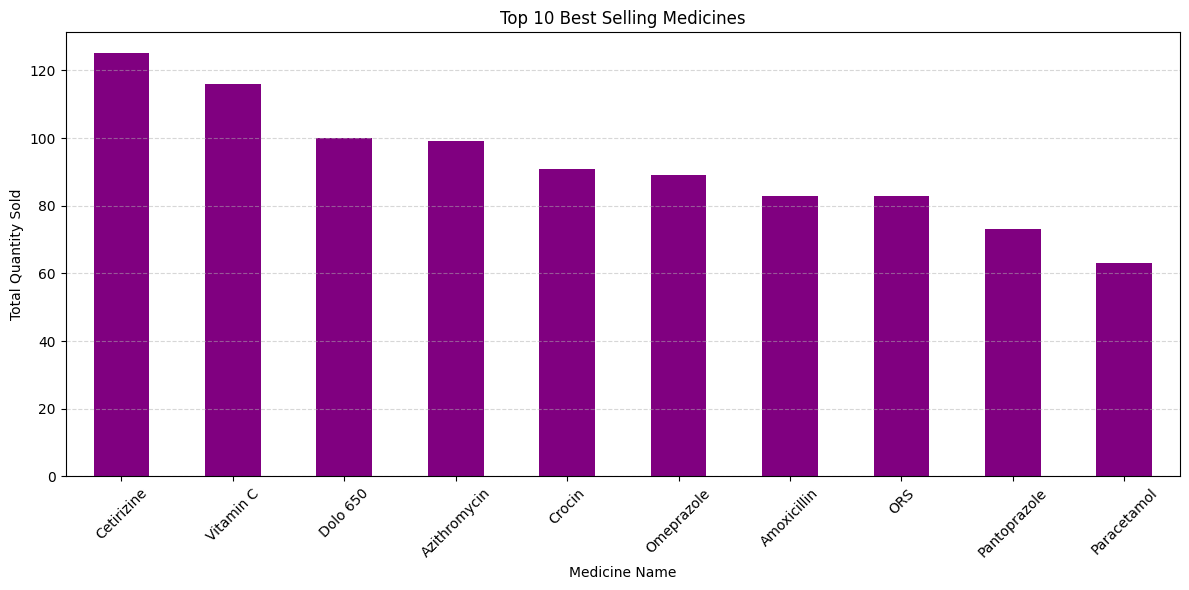

In [17]:
plt.figure(figsize=(12,6))

top_medicines.plot(
    kind="bar",
    color="purple"
)

plt.title("Top 10 Best Selling Medicines")
plt.xlabel("Medicine Name")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [18]:
payment_analysis = (
    df.groupby("Payment_Method")
      .size()
      .sort_values(ascending=False)
)

payment_analysis

Payment_Method
Card    111
UPI      99
Cash     90
dtype: int64

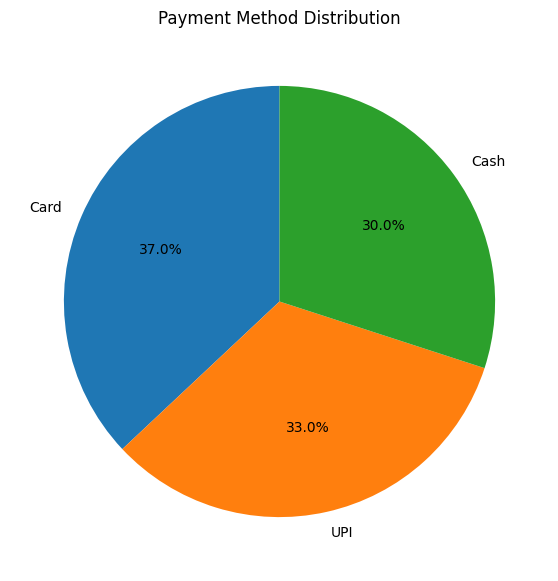

In [20]:
plt.figure(figsize=(7,7))

payment_analysis.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Method Distribution")
plt.ylabel("")

plt.show()

In [21]:
city_revenue = (
    df.groupby("City")["Total_Price"]
      .sum()
      .sort_values(ascending=False)
)

city_revenue

City
Siliguri    28694.00
Durgapur    25074.25
Kolkata     19008.00
Howrah      15893.00
Name: Total_Price, dtype: float64

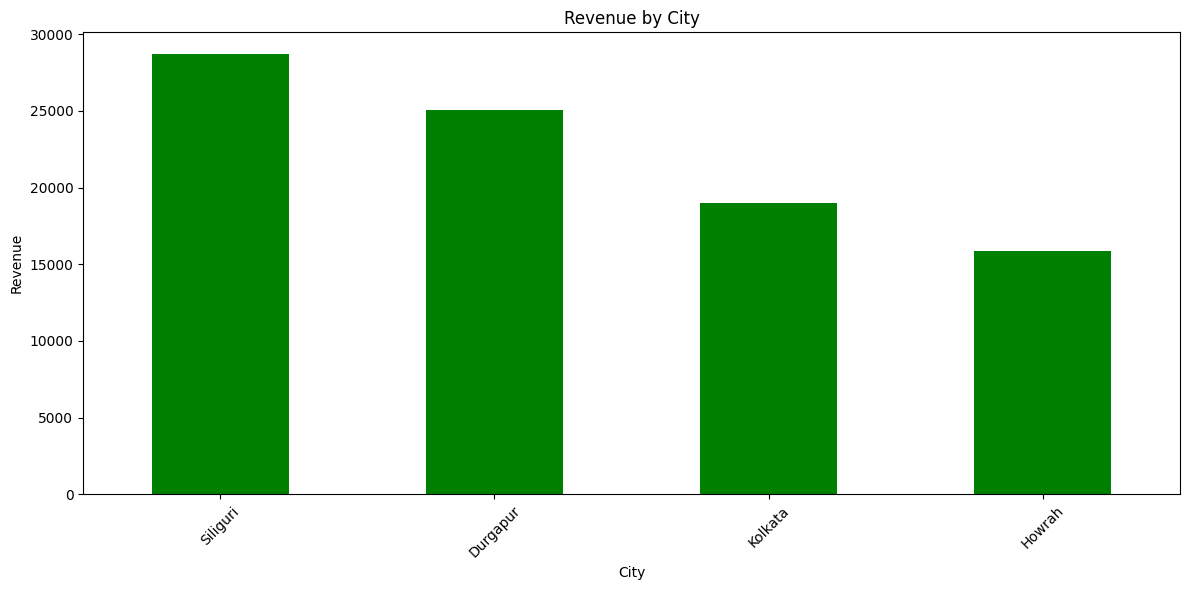

In [22]:
plt.figure(figsize=(12,6))

city_revenue.plot(
    kind="bar",
    color="green"
)

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [23]:
gender_analysis = df["Gender"].value_counts()

gender_analysis

Gender
Male      155
Female    145
Name: count, dtype: int64

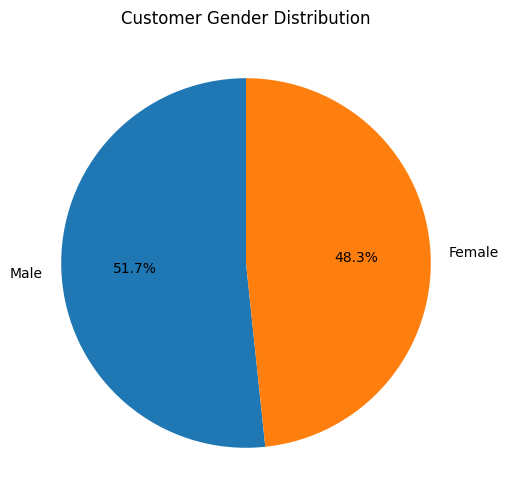

In [24]:
plt.figure(figsize=(6,6))

gender_analysis.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Gender Distribution")
plt.ylabel("")

plt.show()

In [26]:
df["Date"] = pd.to_datetime(df["Date"])

monthly_sales = (
    df.groupby(df["Date"].dt.month_name())["Total_Price"]
      .sum()
)

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = monthly_sales.reindex(month_order).dropna()

monthly_sales

Date
January     13250.50
February    19696.50
March       11552.25
April       13861.25
May         16801.50
June        13507.25
Name: Total_Price, dtype: float64

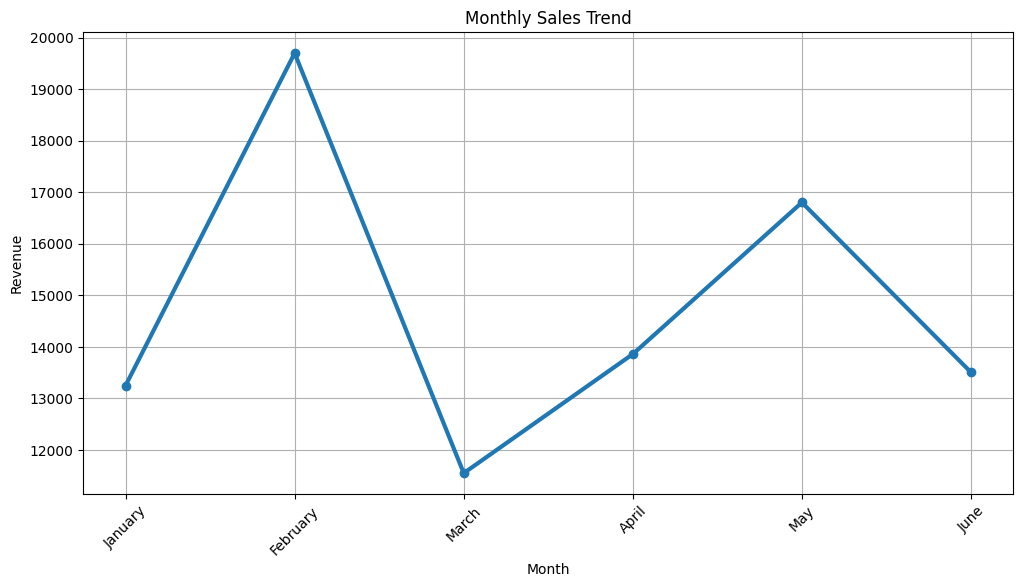

In [27]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=3
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

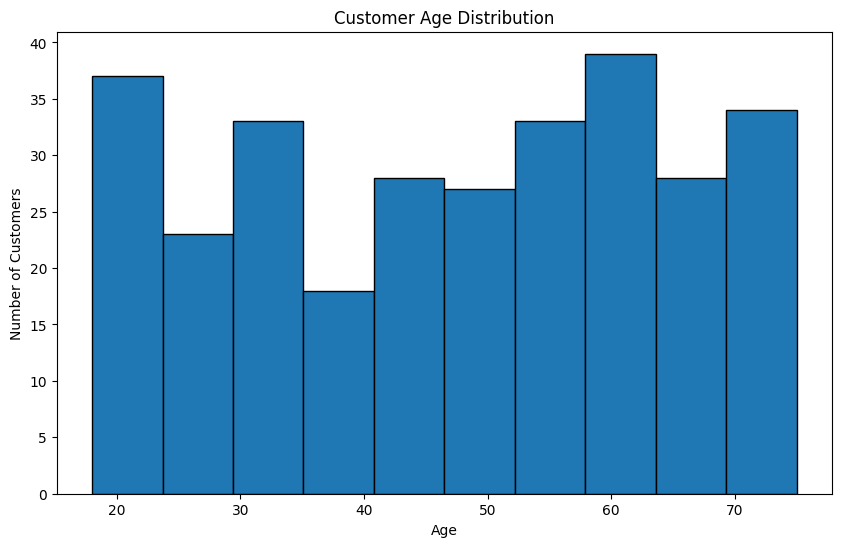

In [28]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Age"],
    bins=10,
    edgecolor="black"
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

In [30]:
low_stock = (
    df.sort_values("Stock")
      .head(10)
)

low_stock

,Invoice_ID,Date,Customer_ID,Gender,Age,Medicine_Name,Category,Brand,Quantity,Unit_Price,Discount,Total_Price,Payment_Method,Supplier,Stock,Expiry_Date,City
24,INV0025,2025-01-28,CUST024,Female,70,Dolo 650,Pain Relief,Cipla,1,75,0,75.0,Card,PharmaLink,5,2026-01-14,Kolkata
74,INV0075,2025-03-21,CUST063,Female,70,Azithromycin,Antibiotic,Abbott,1,180,0,180.0,Card,PharmaLink,5,2026-11-06,Durgapur
244,INV0245,2025-06-06,CUST055,Female,75,ORS,Hydration,Cipla,5,50,10,225.0,UPI,HealthPlus,6,2026-05-31,Siliguri
86,INV0087,2025-02-23,CUST070,Female,71,Pantoprazole,Gastric,Cipla,2,75,10,135.0,UPI,MediSupply,6,2026-06-23,Siliguri
223,INV0224,2025-05-21,CUST111,Female,73,ORS,Hydration,Cipla,5,180,15,765.0,Card,PharmaLink,7,2026-08-09,Siliguri
68,INV0069,2025-04-26,CUST111,Male,39,Dolo 650,Pain Relief,Dr. Reddy's,1,20,10,18.0,UPI,HealthPlus,8,2026-03-10,Kolkata
106,INV0107,2025-01-08,CUST002,Female,23,Amoxicillin,Antibiotic,Cipla,2,250,10,450.0,Card,MediSupply,8,2026-05-16,Howrah
130,INV0131,2025-02-15,CUST037,Female,62,Dolo 650,Pain Relief,Cipla,4,120,0,480.0,UPI,HealthPlus,8,2026-05-22,Durgapur
49,INV0050,2025-02-25,CUST080,Male,59,Azithromycin,Antibiotic,Pfizer,5,180,5,855.0,UPI,PharmaLink,9,2026-03-16,Siliguri
64,INV0065,2025-04-15,CUST054,Male,72,Cetirizine,Allergy,Sun Pharma,2,120,15,204.0,UPI,CareDist,9,2026-10-09,Howrah


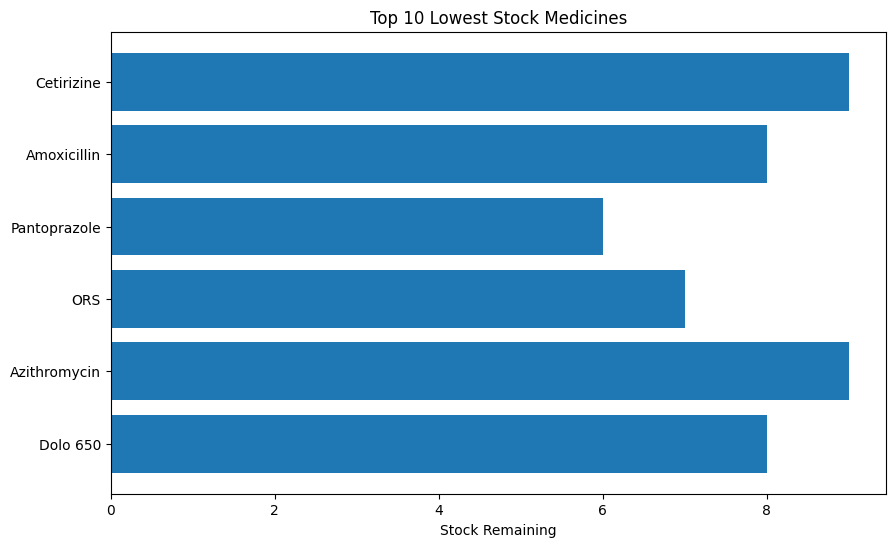

In [31]:
plt.figure(figsize=(10,6))

plt.barh(
    low_stock["Medicine_Name"],
    low_stock["Stock"]
)

plt.title("Top 10 Lowest Stock Medicines")
plt.xlabel("Stock Remaining")

plt.show()

In [32]:
df["Expiry_Date"] = pd.to_datetime(df["Expiry_Date"])

expiry_medicines = df.sort_values("Expiry_Date").head(10)

expiry_medicines[
    ["Medicine_Name", "Expiry_Date", "Stock"]
]

,Medicine_Name,Expiry_Date,Stock
107,Vitamin C,2026-01-04,145
53,Pantoprazole,2026-01-04,62
117,Vitamin C,2026-01-05,84
280,Paracetamol,2026-01-06,168
58,Amoxicillin,2026-01-06,120
119,Dolo 650,2026-01-07,84
207,Cetirizine,2026-01-07,103
192,Vitamin C,2026-01-08,199
37,Crocin,2026-01-09,29
290,Omeprazole,2026-01-09,154


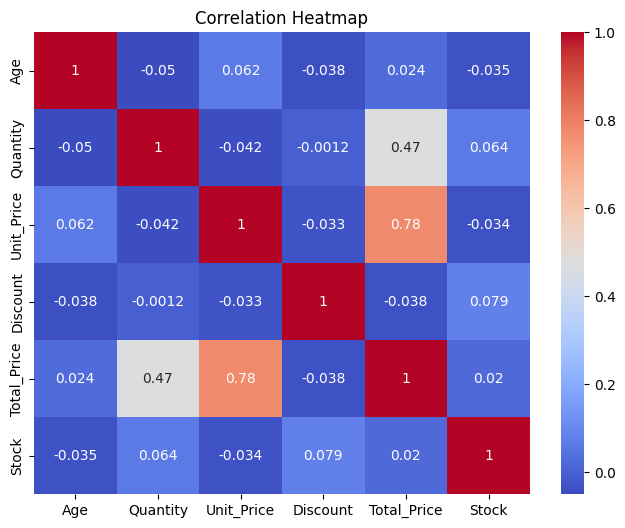

In [36]:
import seaborn as sns
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Age","Quantity","Unit_Price","Discount","Total_Price","Stock"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

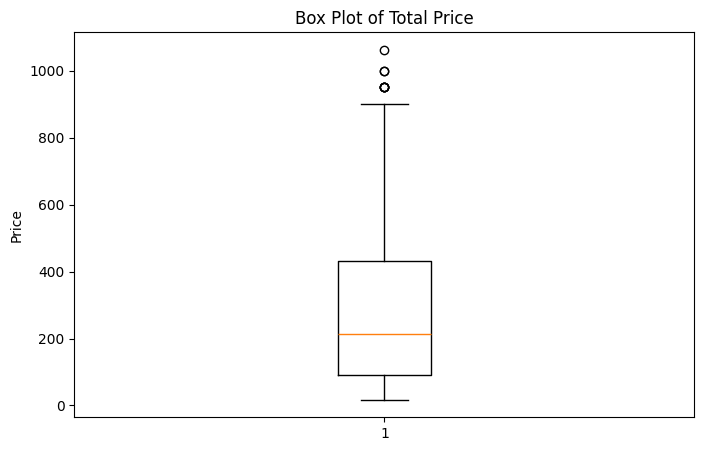

In [38]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Total_Price"])

plt.title("Box Plot of Total Price")

plt.ylabel("Price")

plt.show()

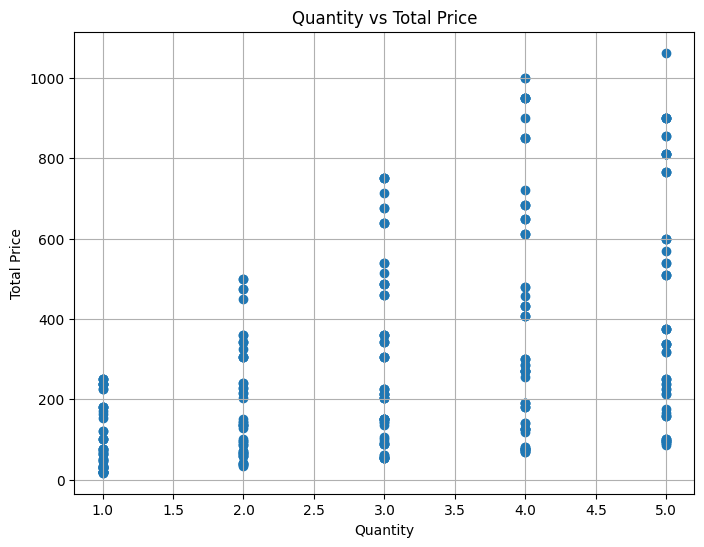

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Quantity"],
    df["Total_Price"]
)

plt.title("Quantity vs Total Price")

plt.xlabel("Quantity")

plt.ylabel("Total Price")

plt.grid(True)

plt.show()

In [40]:
print("="*50)
print("🏥 PharmaPulse KPI Dashboard")
print("="*50)

print(f"💰 Total Revenue : ₹{df['Total_Price'].sum():,.2f}")

print(f"🧾 Total Transactions : {len(df)}")

print(f"💊 Total Medicines : {df['Medicine_Name'].nunique()}")

print(f"🏷️ Total Brands : {df['Brand'].nunique()}")

print(f"🏙️ Cities Covered : {df['City'].nunique()}")

print(f"📦 Average Stock : {df['Stock'].mean():.2f}")

🏥 PharmaPulse KPI Dashboard
💰 Total Revenue : ₹88,669.25
🧾 Total Transactions : 300
💊 Total Medicines : 10
🏷️ Total Brands : 6
🏙️ Cities Covered : 4
📦 Average Stock : 100.81


In [42]:
print("📌 Business Insights")
print("-" * 50)

highest_category = df.groupby("Category")["Total_Price"].sum().idxmax()
highest_brand = df.groupby("Brand")["Total_Price"].sum().idxmax()
preferred_payment = df["Payment_Method"].value_counts().idxmax()
top_medicine = df.groupby("Medicine_Name")["Quantity"].sum().idxmax()
average_age = df["Age"].mean()

print(f"Highest Revenue Category : {highest_category}")
print(f"Highest Revenue Brand : {highest_brand}")
print(f"Most Preferred Payment Method : {preferred_payment}")
print(f"Top Selling Medicine : {top_medicine}")
print(f"Average Customer Age : {average_age:.1f} Years")

📌 Business Insights
--------------------------------------------------
Highest Revenue Category : Pain Relief
Highest Revenue Brand : Cipla
Most Preferred Payment Method : Card
Top Selling Medicine : Cetirizine
Average Customer Age : 47.4 Years
